[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PooryaBehnamie/bioimage-analysis-notebooks/blob/main/Notebook_1_From_Pixels_to_Phenotypes.ipynb)

# From Pixels to Phenotypes: A Gentle Intro to Bioimage Analysis

## Introduction to Bioimage Analysis in Biology

Welcome to this tutorial series! In this first notebook, we introduce fundamental concepts of **image analysis** and **computer vision (CV)** as they apply to biological and medical images. We’ll survey major imaging modalities and how CV is transforming both research and clinical practice. We’ll then focus on fluorescence in situ hybridization (FISH), a powerful technique to visualize DNA/RNA in cells and its role in studying **extrachromosomal DNA (ecDNA)** in cancer. Finally, we’ll get hands-on with a simple Python example to load and manipulate an image, paving the way for more advanced techniques in subsequent notebooks.

**Learning Goals:**
- Understand the basics of image analysis and its importance in biology.
- Learn about common biological imaging modalities and CV applications.
- Gain familiarity with FISH imaging and ecDNA biology.
- Perform basic image loading, inspection, and manipulation in Python.

**Prerequisites:** Basic Python knowledge (e.g., variables, functions). No prior image analysis experience needed.

**Time to Complete:** 45–60 minutes.

**Hardware:** Standard laptop (CPU only).

**Key Terms:** Pixel, channel, modality, FISH, ecDNA.

**Further Reading:** 
- Moore et al. (2021). OME-NGFF: a next-generation file format for expanding bioimaging data-access strategies. *Nature Methods*. [Link](https://doi.org/10.1038/s41592-021-01326-w)
- Bahry et al. (2022). RS-FISH: precise, interactive, fast, and scalable FISH spot detection. *Nature Methods*. [Link](https://doi.org/10.1038/s41592-022-01669-y)

**Author:** Poorya Behnamie
**Last updated:** 2026-09-24

In [1]:
# --- Setup: works locally and on Google Colab ---
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("data").exists():
    # On Colab, fetch the repository so the example data is available
    !git clone -q https://github.com/PooryaBehnamie/bioimage-analysis-notebooks.git
    %cd bioimage-analysis-notebooks

DATA_DIR = Path("data")                      # example images shipped with the repo
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)   # anything we save goes here (git-ignored)

import matplotlib
matplotlib.rcParams["figure.dpi"] = 72       # keeps saved notebooks small; raise for sharper figures

# --- Import libraries ---
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Plotting and visualization
from skimage import io, util      # Image input/output + utilities
import platform, datetime

def pkgver(modname):
    try:
        return getattr(__import__(modname), "__version__", "unknown")
    except Exception as e:
        return f"not installed ({e.__class__.__name__})"

print("Run date:", datetime.datetime.now().isoformat(timespec="seconds"))
print("Python:  ", sys.version.split()[0])
print("Platform:", platform.platform())
for name in ["numpy", "skimage", "cv2", "matplotlib", "tifffile"]:
    print(f"{name:>10}: {pkgver(name)}")

Run date: 2026-09-24T12:01:19
Python:   3.11.15
Platform: Linux-6.18.44-fc-v37-x86_64-with-glibc2.39
     numpy: 2.4.4
   skimage: 0.26.0
       cv2: 4.13.0
matplotlib: 3.10.9
  tifffile: 2026.3.3


## 1. What is Image Analysis and Why Does Biology Need It?

Image analysis extracts meaningful information from images (e.g., shapes, intensities, textures). Computer vision is the broader field where computers are taught to “see” and interpret visual data. In biology and medicine, these tools help handle the massive volume of visual data from modern microscopes, scanners, and imaging devices.

**Why it matters:** Modern imaging can generate thousands of images beyond what a person can review. Automated analysis detects subtle patterns and changes that might be missed by the naked eye, and does so quickly and quantitatively. AI systems can reach expert-level performance in diagnosing diseases from medical images (sometimes matching or exceeding specialists). In radiology, algorithms interpret chest X-rays/CT with near-radiologist performance and have even received FDA clearance as assistive tools to reduce errors. Datasets are also getting huge (a single pathology whole-slide image can be billions of pixels), spurring new formats and tools (e.g., OME-NGFF/OME-Zarr) to manage/share multi-dimensional microscopy data.

**A synergy of fields:**
- For computer science students: Apply algorithms to real biological problems—detecting cancer in tissue images, tracking neurons in videos, etc.
- For biology students: Coding for image analysis unlocks powerful ways to quantify and test hypotheses on visual data (e.g., “How many cancer cells respond to this drug?”). Handling large images and multi-terabyte datasets is increasingly part of the job.

## 2. A Tour of Biological Imaging Modalities


![Image samples from different medical image modalities: radiology, microscopy, dermatology](assets/fig_modalities_sharif2020.png)

**Figure.** Image samples from different medical image modalities (radiology, microscopy, dermatology).  
*Source:* Sharif, S.M.A.; Naqvi, R.A.; Biswas, M. 
- **Learning Medical Image Denoising with Deep Dynamic Residual Attention Network.**
- *Mathematics* 2020, 8(12), 2192. https://doi.org/10.3390/math8122192
- **License:** CC BY 4.0 (https://creativecommons.org/licenses/by/4.0/). *No changes made*.

*Below are five representative modalities (from clinical imaging to microscopy) and how CV helps in each.*

### 1) X-rays (Radiography)
2D projections (e.g., chest radiographs) acquired quickly and at scale. Deep models screen for pneumonia, tuberculosis, fractures and more, reaching radiologist-level performance on several benchmark tasks [2]; used as assistive tools, they have improved radiologists' detection of findings in reader studies [3]. Many such tools are now FDA-cleared as decision support [4].

### 2) CT (Computed Tomography)
3D stacks reconstructed from many X-ray angles. CV aids detection of lung nodules, bleeds and other findings; deep-learning nodule detectors reach sensitivities comparable to radiologists, typically with a trade-off in false positives, and are most useful as a **second reader** [5].

### 3) MRI (Magnetic Resonance Imaging)
High-contrast soft-tissue imaging (brain, heart, musculoskeletal), often multi-sequence, 3D and time-resolved. CV supports segmentation (tumors, organs), longitudinal tracking, and deep-learning reconstruction that allows **several-fold faster acquisitions** with diagnostic quality comparable to standard protocols in studied settings [6].

### 4) Histopathology (Whole-Slide Imaging, H&E)
Gigapixel slides at cellular resolution. AI can detect cancer, **grade** tumors, and even **infer molecular alterations** from morphology. In the PANDA challenge, top algorithms reached **pathologist-level** agreement for prostate biopsy Gleason grading on external cohorts [7]. Managing images at this scale benefits from cloud-optimized formats such as OME-Zarr [1].

![Typical workflow of WSI segmentation: patching, feature extraction / DL models, clustering, ROI & nuclei masks](assets/fig_wsi_seg_workflow_althelaya2023.jpg)

**Figure.** Typical workflow of WSI segmentation applications.  
*Source:* Al-Thelaya, K. **et al.** *Applications of discriminative and deep learning feature extraction methods for whole slide image analysis: A survey.* 
- **Journal of Pathology Informatics** (2023). https://doi.org/10.1016/j.jpi.2023.100335
- **License:** CC BY-NC-ND 4.0. *No changes made.* 

### 5) Fluorescence Microscopy (incl. FISH)
Cells/tissues are labeled with fluorescent probes. Images often have bright signals on dark background (single molecules, loci, organelles). Tasks include spot counting, segmentation, colocalization, and tracking. Multiplexed assays (e.g., spatial transcriptomics, high-plex FISH) produce **hundreds of markers** imaged iteratively, demanding robust, automated analysis and data structures [8–10]. Tools like **TrackMate 7** integrate deep-learning segmentation for robust object tracking in microscopy movies [11].

**Why Important for Clinicians and Scientists:** CV accelerates diagnosis (e.g., faster tumor grading), enables large-scale studies (e.g., population-level cancer screening), and uncovers hidden patterns (e.g., spatial gene expression in tissues). In research, it quantifies biological processes objectively; clinically, it reduces errors and supports personalized medicine.

## 3. Focus on FISH: Visualizing Genes and Molecules in Cells


![RS-FISH detects fluorescent spots across noise levels and scales to large 2D/3D datasets](assets/fig_rs-fish_bahry2022.png)

**Figure.** RS-FISH accurately detects fluorescent spots. Panels illustrate RS-RANSAC gradient consensus, splitting close spots, anisotropy handling, exporting detections, multi-fluor barcodes, and cluster/cloud scaling.  
*Source:* Bahry, E. **et al.** *RS-FISH: precise, interactive, fast, and scalable FISH spot detection.* 
- **Nature Methods** (2022). https://doi.org/10.1038/s41592-022-01669-y
- **License:** CC BY 4.0. *No changes made.*

#### **What is FISH?** 
In situ hybridization binds fluorescently labeled oligonucleotide probes to target DNA/RNA sequences within fixed cells/tissues, creating localized fluorescent spots. **DNA FISH** targets genomic loci (e.g., HER2 amplification in breast cancer). **RNA FISH**/**smFISH** detects single mRNA molecules. Because FISH preserves spatial context (which cell, which subcellular region), it directly links molecular identity to morphology [8–10].

**How FISH images are produced.** Samples are fixed and permeabilized, fluorescent probes hybridize to targets, excess is washed, and images are acquired in one or more channels:
- **Context channel**, e.g., **DAPI** nuclear stain (blue).
- **Probe channels** for targets (e.g., red/green spots).
A bright spot ≈ many copies of a DNA target clustered locally (or a single RNA molecule in smFISH).

**Applications:** Clinical cytogenetics (translocations, gene amplifications like **HER2**, **BCR-ABL**), and research on genome architecture and gene expression. Modern multiplexed methods (e.g., **Oligopaint**, **seqFISH**, **MERFISH**, **DART-FISH**) scale to **dozens–hundreds** of targets across iterative imaging rounds, enabling spatial omics at single-cell resolution [8–10].

**Analysis challenges & modern solutions:**
Spot intensities vary; signals overlap; background and autofluorescence exist; 3D stacks and large tissue areas increase complexity. Classical threshold+filter pipelines often require per-dataset tuning. Newer CV includes:  
- **RS-FISH** (Radial Symmetry FISH): precise, scalable 2D/3D spot localization with outlier-robust consensus (RANSAC), splitting merged spots and maintaining accuracy in noisy volumes [12].  
- **DL-based** segmentation and detection for nuclei/cells/spots, often improving robustness in weak or crowded signals.

## 4. Extrachromosomal DNA (ecDNA): A Case Study for FISH Analysis

![FISH ecDNA study: dual-probe metaphase image; heterogeneity schematic; JQ1 mechanism; AI vs. experimental counts; reintegration to HSRs; multimer/hub structures; model & statistics](assets/fig_ecdna_brunk2025_fig3.jpg)

**Figure.** Scaling data analytics to probe ecDNA-mediated drug response. (A) Dual-probe metaphase FISH of NCI-H2170 cells; (B) multiple ecDNA species create cell-to-cell heterogeneity; (C) JQ1/BRD4 schematic; (D) experimental and AI-predicted (MIA, ecSeg) ecDNA counts in control vs. JQ1-treated cells; (E–G) reintegration into HSRs and multimerized ecDNA ("hubs"); (H–J) reintegration model and summary statistics.
*Source:* Goble, K., … Brunk, E. *Leveraging AI to automate detection and quantification of extrachromosomal DNA to decode drug responses.*
- **Frontiers in Pharmacology** 15:1516621 (2025). https://doi.org/10.3389/fphar.2024.1516621
- **License:** CC BY 4.0. *No changes made.*

#### **What is ecDNA?**

Circular DNA elements outside chromosomes that often carry **oncogenes**. Lacking centromeres, they **segregate unevenly** during mitosis, creating dramatic **copy-number heterogeneity** across cells and enabling rapid tumor evolution and drug resistance [13–15].

**Why ecDNA matters.** A pan-cancer analysis of ~15,000 patients found ecDNA in about **17%** of tumour samples, with much higher rates in some tumour types (e.g., glioblastoma, sarcomas) [13]. ecDNA is associated with poorer outcomes and therapy resistance. ecDNA chromatin is unusually accessible, and ecDNAs can cluster into **hubs** that cooperatively drive **high oncogene transcription** [14]. Distinct ecDNA species can also be **co-inherited** during cell division rather than segregating fully independently [15].

**ecDNA in FISH.** With a probe targeting an ecDNA-borne oncogene, ecDNA(+) nuclei often show **many dispersed spots** rather than two chromosomal loci; **hubs** appear as bright clusters. In **metaphase spreads** (the image we use below), ecDNA appear as small **acentric "double minutes"** scattered among the condensed chromosomes [16].

**Why automate?** Manual counting is time-consuming and subjective. An automated pipeline can:
- Detect/count spots per cell (ecDNA copies),
- Quantify **intensity/size** (hub proxy),
- Measure **spatial patterns** (e.g., nuclear periphery vs. interior),
- Scale across thousands of cells consistently, enabling screening and research, and potentially informing clinical triage where ecDNA-positive tumors may need alternative strategies.

**Recent discoveries (fun facts):** ecDNAs can cluster into multi-copy hubs (Hung et al., 2021) and different ecDNA species can be co-inherited during division (Hung et al., 2024), i.e., different ecDNAs "team up," yielding coordinated inheritance beyond pure randomness. These insights rely on single-cell analyses and advanced imaging.

## 5. First Steps: Viewing and Manipulating Images with Python

We'll rely mainly on **scikit-image** and **NumPy** (with occasional **OpenCV**) for basic I/O and manipulation, and **matplotlib** for visualization.

**Image basics.** A grayscale image is a 2D array of intensities. Color or multi-channel fluorescence images are 3D arrays: `(H, W, C)`. Scientific images are often **16-bit** (`uint16`, 0–65535) rather than 8-bit.

> **Tip:** Preserve bit depth and channel order. OpenCV loads BGR by default; scikit-image and matplotlib use RGB. For large TIFFs/stacks, prefer libraries and formats that handle **multi-dimensional data** (OME-TIFF, OME-Zarr) [1].

### Our example data
The `data/` folder contains one **metaphase FISH image** of NCI-H2170 lung cancer cells, distributed openly by the Brunk Lab with the [ecEnhance](https://github.com/Brunk-Lab/ecEnhance) pipeline (MIT License):

| File | What it is |
|---|---|
| `fish_rgb.tif` | RGB **display composite**: DAPI (chromosomes) rendered in gray, **ERBB2/HER2 probe in red**, **MYC probe in green** |
| `fish_dapi.tif` | DAPI channel, cropped by an expert to the metaphase spread (pixels outside the region of interest are 0) |
| `fish_mia_mask.tif` | ecDNA spots predicted by MIA, a U-Net-based tool used in Goble et al. (2025). A model output, **not** ground truth |

Setup instructions are in the repository README.

Image shape: (2048, 2448, 3)
Data type:   uint8


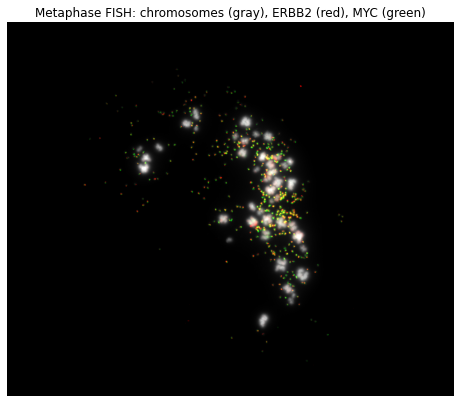

In [2]:
# Load the RGB composite
image = io.imread(DATA_DIR / "fish_rgb.tif")

print("Image shape:", image.shape)   # (height, width, channels)
print("Data type:  ", image.dtype)   # uint8 (0-255) or uint16 (0-65535)

plt.figure(figsize=(8, 7))
plt.imshow(image)
plt.title("Metaphase FISH: chromosomes (gray), ERBB2 (red), MYC (green)")
plt.axis("off")
plt.show()

### A merged RGB image is not raw channel data

Microscopes record each fluorophore as a **separate grayscale channel**. The file above is a *display composite* that someone made for viewing. Here, the DAPI signal was painted **gray**, which means it was added **equally to R, G and B**. So:

- channel 0 (**R**) = DAPI + red probe
- channel 1 (**G**) = DAPI + green probe
- channel 2 (**B**) = mostly DAPI

A common beginner's mistake is to assume "channel 0 is DAPI" or "blue is always the nucleus". Let's look at each channel and see what it really contains.

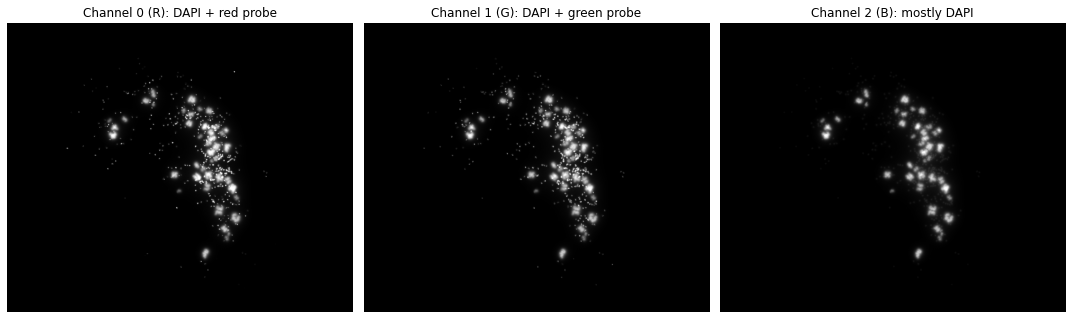

In [3]:
R, G, B = image[..., 0], image[..., 1], image[..., 2]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, ch, name in zip(axs, [R, G, B], ["Channel 0 (R): DAPI + red probe",
                                          "Channel 1 (G): DAPI + green probe",
                                          "Channel 2 (B): mostly DAPI"]):
    ax.imshow(ch, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

Because the gray DAPI contributes the same amount to every channel, subtracting the blue channel removes it and leaves the **probe signal**. We convert to a signed type first so the subtraction cannot wrap around below zero (more on this *integer overflow* in Notebook 2). We zoom into a small region so individual ecDNA spots are visible.

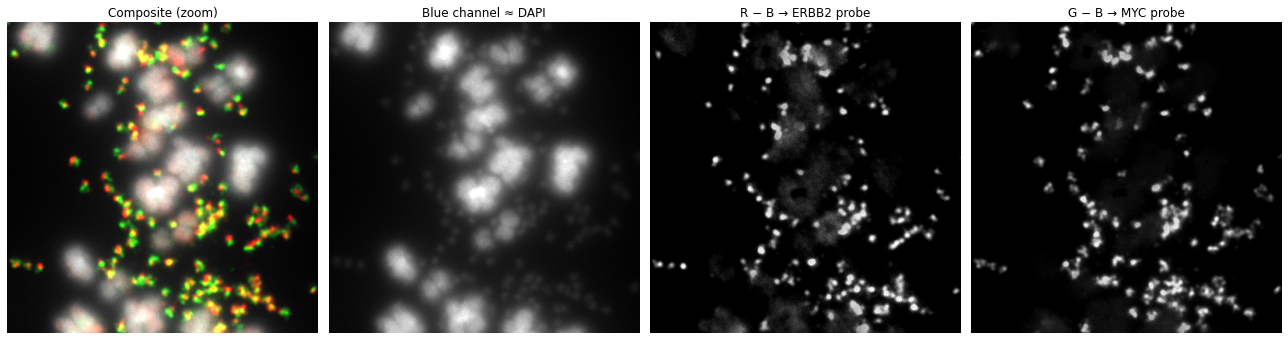

In [4]:
rgb16 = image.astype(np.int16)                               # signed, so negatives are allowed
red_probe   = np.clip(rgb16[..., 0] - rgb16[..., 2], 0, 255).astype(np.uint8)
green_probe = np.clip(rgb16[..., 1] - rgb16[..., 2], 0, 255).astype(np.uint8)

# Zoom into a 400 x 400 region inside the metaphase spread
ys, xs = slice(700, 1100), slice(1250, 1650)

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
axs[0].imshow(image[ys, xs]);                   axs[0].set_title("Composite (zoom)")
axs[1].imshow(B[ys, xs], cmap="gray");          axs[1].set_title("Blue channel ≈ DAPI")
axs[2].imshow(red_probe[ys, xs], cmap="gray");  axs[2].set_title("R − B → ERBB2 probe")
axs[3].imshow(green_probe[ys, xs], cmap="gray");axs[3].set_title("G − B → MYC probe")
for ax in axs: ax.axis("off")
plt.tight_layout()
plt.show()

The DAPI channel is also provided as its own file. Note that it was cropped to the metaphase spread by an expert, so it doubles as a **region of interest**.

DAPI shape: (2048, 2448) | dtype: uint8


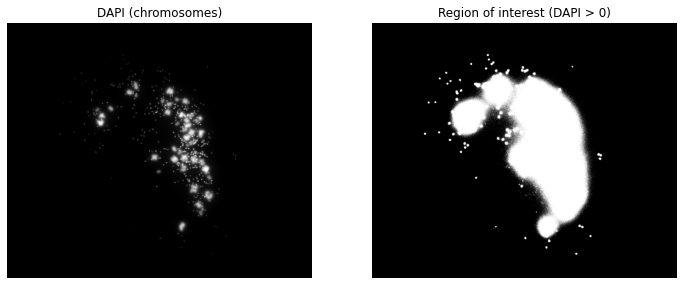

In [5]:
dapi = io.imread(DATA_DIR / "fish_dapi.tif")
print("DAPI shape:", dapi.shape, "| dtype:", dapi.dtype)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(dapi, cmap="gray");  axs[0].set_title("DAPI (chromosomes)")
axs[1].imshow(dapi > 0, cmap="gray"); axs[1].set_title("Region of interest (DAPI > 0)")
for ax in axs: ax.axis("off")
plt.show()

### Basic manipulations: rotate, reorder channels, convert to grayscale, save

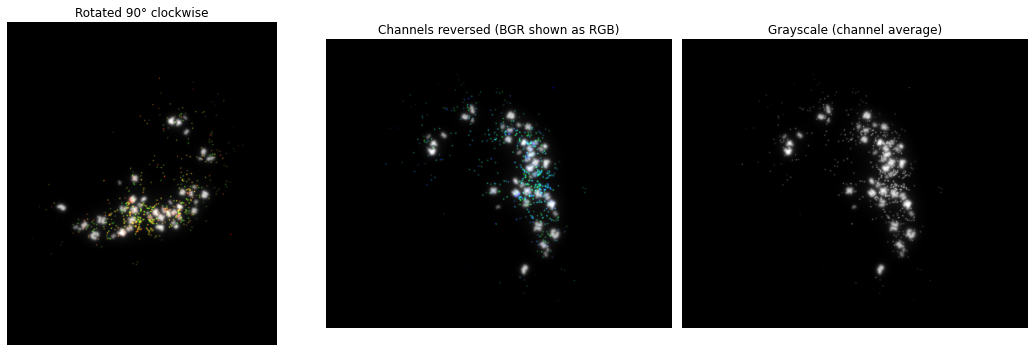

Saved outputs/rotated_fish.tif


In [6]:
# Rotate 90° clockwise
rotated = np.rot90(image, k=-1)          # k=-1 means clockwise

# Reorder channels (RGB -> BGR, as OpenCV would store it)
swapped = image[:, :, ::-1]

# Convert to grayscale (simple average across channels)
grayscale = util.img_as_float(image).mean(axis=2)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(rotated);                 axs[0].set_title("Rotated 90° clockwise")
axs[1].imshow(swapped);                 axs[1].set_title("Channels reversed (BGR shown as RGB)")
axs[2].imshow(grayscale, cmap="gray");  axs[2].set_title("Grayscale (channel average)")
for ax in axs: ax.axis("off")
plt.tight_layout()
plt.show()

# Save the rotated image to the outputs/ folder (kept out of the repository)
io.imsave(OUT_DIR / "rotated_fish.tif", rotated, check_contrast=False)
print("Saved", OUT_DIR / "rotated_fish.tif")

**Your Turn:** Look at the grayscale image above. Can you still tell the red (ERBB2) and green (MYC) spots apart? Converting to grayscale too early **throws away probe identity**. In ecDNA work that would mean you can no longer ask *which oncogene* a spot carries.

**Notes:** scikit-image preserves bit depth. With OpenCV, use `cv2.imread(path, cv2.IMREAD_UNCHANGED)` to keep 16-bit data, and remember it returns channels in **BGR** order.

## 6. What's Next

In this notebook, we covered image analysis basics, key modalities, FISH/ecDNA biology, and how to load and inspect a real FISH image.

- **Notebook 2 (Images as arrays):** data types and dynamic range, color spaces, masking with the DAPI region, and a first object detector (connected components) applied to the ecDNA probe signal.
- **Notebook 3 (Classical → Deep learning):** the optics behind spots (PSF), Gaussian filtering, background removal, morphology, LoG and watershed, then a small **U-Net trained on synthetic spots** and compared with LoG using precision, recall and F1.

**Reflection:** Why is automating FISH spot detection useful for pathologists and cancer biologists?
*(Hint: scale, consistency, quantitative insights.)*

Happy imaging! 🚀

## References

1. **Moore, J. et al.** (2021). OME-NGFF: a next-generation file format for expanding bioimaging data-access strategies. *Nature Methods* 18:1496–1498. https://doi.org/10.1038/s41592-021-01326-w
2. **Rajpurkar, P. et al.** (2018). Deep learning for chest radiograph diagnosis: a retrospective comparison of the CheXNeXt algorithm to practicing radiologists. *PLOS Medicine* 15:e1002686. https://doi.org/10.1371/journal.pmed.1002686
3. **Seah, J.C.Y. et al.** (2021). Effect of a comprehensive deep-learning model on the accuracy of chest x-ray interpretation by radiologists: a retrospective, multireader multicase study. *Lancet Digital Health* 3:e496–e506. https://doi.org/10.1016/S2589-7500(21)00106-0
4. **U.S. FDA.** Artificial Intelligence-Enabled Medical Devices (public list). https://www.fda.gov/medical-devices/software-medical-device-samd/artificial-intelligence-enabled-medical-devices
5. **Hendrix, W. et al.** (2023). Deep learning for the detection of benign and malignant pulmonary nodules in non-screening chest CT scans. *Communications Medicine* 3:156. https://doi.org/10.1038/s43856-023-00388-5
6. **Recht, M.P. et al.** (2020). Using deep learning to accelerate knee MRI at 3 T: results of an interchangeability study. *AJR* 215:1421–1429. https://doi.org/10.2214/AJR.20.23313
7. **Bulten, W. et al.** (2022). Artificial intelligence for diagnosis and Gleason grading of prostate cancer: the PANDA challenge. *Nature Medicine* 28:154–163. https://doi.org/10.1038/s41591-021-01620-2
8. **Beliveau, B.J. et al.** (2012). Versatile design and synthesis platform for visualizing genomes with Oligopaint FISH probes. *PNAS* 109:21301–21306. https://doi.org/10.1073/pnas.1213818110
9. **Chen, K.H. et al.** (2015). Spatially resolved, highly multiplexed RNA profiling in single cells (MERFISH). *Science* 348:aaa6090; **Eng, C.-H.L. et al.** (2019). Transcriptome-scale super-resolved imaging in tissues by RNA seqFISH+. *Nature* 568:235–239.
10. **Kalhor, K. et al.** (2024). Mapping human tissues with highly multiplexed RNA in situ hybridization (DART-FISH). *Nature Communications* 15:2511. https://doi.org/10.1038/s41467-024-46437-y
11. **Ershov, D. et al.** (2022). TrackMate 7: integrating state-of-the-art segmentation algorithms into tracking pipelines. *Nature Methods* 19:829–832. https://doi.org/10.1038/s41592-022-01507-1
12. **Bahry, E. et al.** (2022). RS-FISH: precise, interactive, fast, and scalable FISH spot detection. *Nature Methods* 19:1563–1567. https://doi.org/10.1038/s41592-022-01669-y
13. **Bailey, C. et al.** (2024). Origins and impact of extrachromosomal DNA. *Nature* 635:193–200. https://doi.org/10.1038/s41586-024-08107-3
14. **Hung, K.L. et al.** (2021). ecDNA hubs drive cooperative intermolecular oncogene expression. *Nature* 600:731–736. https://doi.org/10.1038/s41586-021-04116-8
15. **Hung, K.L. et al.** (2024). Coordinated inheritance of extrachromosomal DNAs in cancer cells. *Nature* 635:201–209. https://doi.org/10.1038/s41586-024-07861-8
16. **Purshouse, K., Pollard, S.M. & Bickmore, W.A.** (2024). Imaging extrachromosomal DNA (ecDNA) in cancer. *Histochemistry and Cell Biology* 162:53–64. https://doi.org/10.1007/s00418-024-02280-2
17. **Sharif, S.M.A., Naqvi, R.A. & Biswas, M.** (2020). Learning medical image denoising with deep dynamic residual attention network. *Mathematics* 8:2192. https://doi.org/10.3390/math8122192 (CC BY 4.0)
18. **Goble, K. et al.** (2025). Leveraging AI to automate detection and quantification of extrachromosomal DNA to decode drug responses. *Frontiers in Pharmacology* 15:1516621. https://doi.org/10.3389/fphar.2024.1516621
19. **Fiorini, E. et al.** (2025). MYC ecDNA promotes intratumour heterogeneity and plasticity in PDAC. *Nature* 640:811–820. https://doi.org/10.1038/s41586-025-08721-9 *(further reading)*

---

### Acknowledgements

This notebook was prepared with the assistance of AI tools (ChatGPT, Grok, Gemini and Claude), which were used to help draft, edit, test and refine the code and explanatory text. Final responsibility for scientific accuracy, structure and educational content rests with the author.

Example FISH data: Brunk Lab, [ecEnhance](https://github.com/Brunk-Lab/ecEnhance) repository (MIT License).